In [ ]:
#importing libraries
import pandas as pd #handling datasets
import numpy as np #numerical calculations
import matplotlib.pyplot as plt #plot graphs
from sklearn.model_selection import train_test_split #to split the dataset to train and test
from sklearn.linear_model import LinearRegression
import seaborn as sns #for data visualization


# Load the dataset
data = pd.read_csv('SuperMarket Analysis.csv')

# **Data preprocessing**

In [ ]:
#Convert Date and Time fields to proper datetime formats
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')

data['Time'] = pd.to_datetime(data['Time'], format='%I:%M:%S %p').dt.time

In [ ]:
# Save original shape
original_shape = data.shape

# Check and remove duplicates if any are present:
duplicate_count = data.duplicated().sum()
data = data.drop_duplicates()

# Check and remove missing values if any are present:
missing_count = data.isnull().sum().sum()
data = data.dropna()

# Check new shape
new_shape = data.shape

# Show what changed
print(f"Original shape: {original_shape}")
print(f"New shape: {new_shape}")
print(f"Duplicates removed: {duplicate_count}")
print(f"Missing values removed: {missing_count}")
print(f"Rows removed in total: {original_shape[0] - new_shape[0]}")


Original shape: (1000, 17)
New shape: (1000, 17)
Duplicates removed: 0
Missing values removed: 0
Rows removed in total: 0


In [ ]:
#Encode categorical variables
data_encoded = pd.get_dummies(data, columns=['Branch', 'City', 'Customer type', 'Gender', 'Payment', 'Product line'], drop_first=True)

In [ ]:
# After removing duplicates and missing values
from sklearn.preprocessing import StandardScaler # Import the StandardScaler

# Encode categorical variables first using pd.get_dummies (recommended)
data_encoded = pd.get_dummies(data, columns=['Branch', 'City', 'Customer type', 'Gender', 'Payment', 'Product line'], drop_first=True)

# Then standardize numeric columns
scaler = StandardScaler()
data_encoded[['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'gross margin percentage', 'gross income', 'Rating']] = scaler.fit_transform(
    data_encoded[['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'gross margin percentage', 'gross income', 'Rating']]
)


# **Descriptive Statistics Function**

In [ ]:
# Calculate Measures of Central Tendency
def desc_stat(data, field):
    # Calculate Measures of Central Tendency
    mean_value = data[field].mean()
    median_value = data[field].median()
    mode_value = data[field].mode()[0]  # Handle multiple modes

    # Calculate Measures of Dispersion
    min_value = data[field].min()
    max_value = data[field].max()
    range_value = max_value - min_value
    std_dev_value = data[field].std()
    variance_value = data[field].var()

    # Calculate Measures of Position
    q1 = data[field].quantile(0.25)
    q3 = data[field].quantile(0.75)
    iqr = q3 - q1
    skew_value = data[field].skew()
    kurtosis_value = data[field].kurt()

    # Summary dictionary
    summary = {
        f"Mean {field}": mean_value,
        f"Median {field}": median_value,
        f"Mode {field}": mode_value,
        f"Min {field}": min_value,
        f"Max {field}": max_value,
        f"Range {field}": range_value,
        f"Standard Deviation {field}": std_dev_value,
        f"Variance {field}": variance_value,
        f"Q1 {field}": q1,
        f"Q3 {field}": q3,
        f"IQR {field}": iqr,
        f"Skew {field}": skew_value,
        f"Kurtosis {field}": kurtosis_value,
    }

    return summary

# Example usage
desc_stats = desc_stat(data, 'Sales')
print(desc_stats)


{'Mean Sales': np.float64(322.966749), 'Median Sales': 253.848, 'Mode Sales': np.float64(87.234), 'Min Sales': 10.6785, 'Max Sales': 1042.65, 'Range Sales': 1031.9715, 'Standard Deviation Sales': 245.88533510097207, 'Variance Sales': 60459.598017717326, 'Q1 Sales': np.float64(124.422375), 'Q3 Sales': np.float64(471.35024999999996), 'IQR Sales': np.float64(346.927875), 'Skew Sales': np.float64(0.8925698049581418), 'Kurtosis Sales': np.float64(-0.08188475790435135)}


# **Sampling**

In [ ]:
# Randomly sample 150 records from the data with random state for reproducibility
sample_data = data.sample(n=150, random_state=42)

# Apply the descriptive statistics function on the dependent variable (e.g., 'Sales')
desc_stats_sample = desc_stat(sample_data, 'Sales')

# Print the descriptive statistics for the sample
print(desc_stats_sample)

{'Mean Sales': np.float64(325.49489), 'Median Sales': 234.486, 'Mode Sales': np.float64(10.6785), 'Min Sales': 10.6785, 'Max Sales': 942.4485, 'Range Sales': 931.77, 'Standard Deviation Sales': 253.8220316840476, 'Variance Sales': 64425.623768217665, 'Q1 Sales': np.float64(127.40175), 'Q3 Sales': np.float64(462.952875), 'IQR Sales': np.float64(335.551125), 'Skew Sales': np.float64(0.8216814338811321), 'Kurtosis Sales': np.float64(-0.38947439553037455)}


In [ ]:
# Perform systematic sampling to select every 7th record from the random sample
systematic_sample = data.iloc[::7]

# Apply the descriptive statistics function to the 'Sales' column of the systematic sample
desc_stats_sys = desc_stat(systematic_sample, 'Sales')

# Print the descriptive statistics
print(desc_stats_sys)


{'Mean Sales': np.float64(328.7768811188811), 'Median Sales': 252.252, 'Mode Sales': np.float64(23.499), 'Min Sales': 23.499, 'Max Sales': 1042.65, 'Range Sales': 1019.1510000000001, 'Standard Deviation Sales': 264.6442555933192, 'Variance Sales': 70036.58201854207, 'Q1 Sales': np.float64(97.73400000000001), 'Q3 Sales': np.float64(505.59075), 'IQR Sales': np.float64(407.85675000000003), 'Skew Sales': np.float64(0.9295361555632179), 'Kurtosis Sales': np.float64(-0.12765758201733002)}


# detailed descriptive statistics

In [ ]:
data['Sales'].describe()

,Sales
count,1000.000000
mean,322.966749
std,245.885335
min,10.678500
25%,124.422375
50%,253.848000
75%,471.350250
max,1042.650000


# **Data visualization**

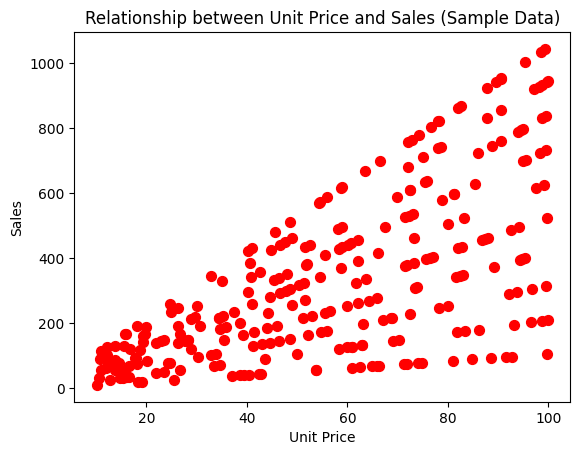

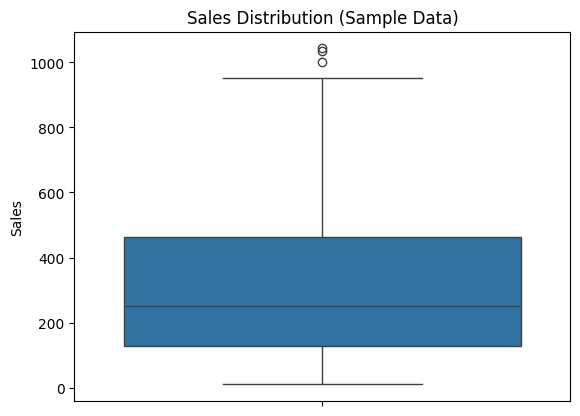

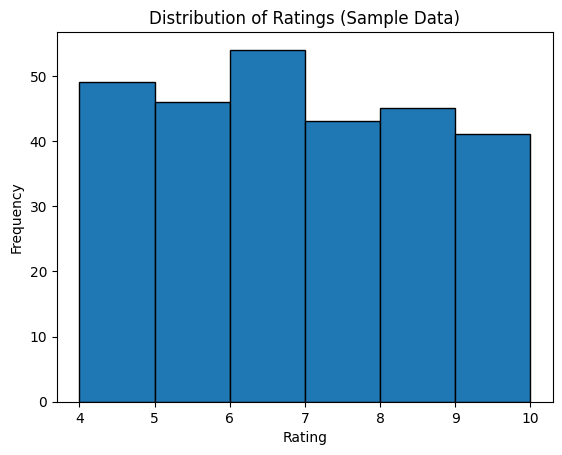

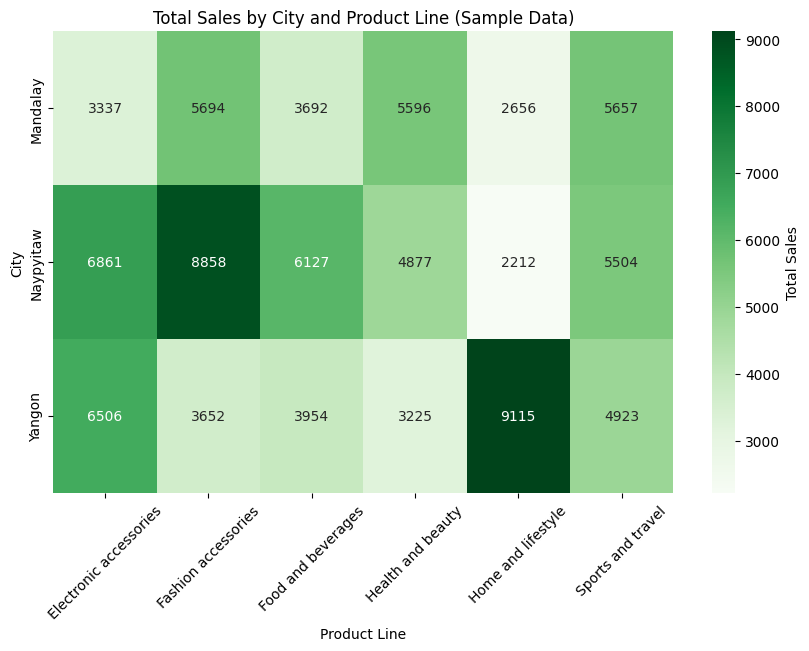

In [ ]:
# Take a sample from the dataset
sample_size = 278
sample_data = data.sample(n=sample_size, random_state=42)

# Scatter Plot (Unit Price vs Sales)
sample_data.plot.scatter(x='Unit price', y='Sales', s=50, c='red')
plt.xlabel('Unit Price')
plt.ylabel('Sales')
plt.title('Relationship between Unit Price and Sales (Sample Data)')
plt.show()

#It helps identify if higher-priced products generate more or fewer sales.
# If there is no clear trend, price might not significantly influence sales.

# Box Plot (Sales Distribution)
sns.boxplot(y=sample_data['Sales'])
plt.ylabel('Sales')
plt.title('Sales Distribution (Sample Data)')
plt.show()

#Shows the range of sales values, the median, and any outliers.
# If there are many outliers, some transactions have exceptionally high sales.

# Histogram (Ratings Distribution)
plt.hist(sample_data['Rating'], bins=6, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings (Sample Data)')
plt.show()

# Helps understand how customers rate their shopping experience.
# If the distribution is skewed, it indicates more positive or negative reviews.


# Create a heat map for Total Sales by City and Product Line
heatmap_data = sample_data.pivot_table(index='City', columns='Product line', values='Sales', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Greens", cbar_kws={'label': 'Total Sales'})
plt.title('Total Sales by City and Product Line (Sample Data)')
plt.ylabel('City')
plt.xlabel('Product Line')
plt.xticks(rotation=45)
plt.show()

# **Hypothesis test**

In [ ]:
# A. Null Hypothesis (H₀): There is no significant correlation between Unit Price and Sales.
# B. Alternative Hypothesis (H₁): There is a significant correlation between Unit Price and Sales.
from scipy.stats import spearmanr

# Compute Spearman's correlation
r, p = spearmanr(sample_data['Unit price'], sample_data['Sales'])

# Print results with better formatting
print(f"Spearman correlation coefficient (r): {r:.3f}")
print(f"P-value:",p)
print(f"P-value after formating: {p:.6f}")

# Interpret significance
if p < 0.05:
    print("\nSince the p-value is less than 0.05: \n-the correlation is statistically significant.\n-the null hypothesis is rejected")
else:
    print("\nSince the p-value is greater than 0.05: \n-The correlation is not statistically significant.\n-the null hypothesis is accepted")


Spearman correlation coefficient (r): 0.669
P-value: 1.9575044448226406e-37
P-value after formating: 0.000000

Since the p-value is less than 0.05: 
-the correlation is statistically significant.
-the null hypothesis is rejected


In [ ]:
from scipy.stats import pearsonr

# Compute Pearson correlation
r, p = pearsonr(sample_data['Quantity'], sample_data['gross income'])

# Print results with better formatting
print(f"Pearson correlation coefficient (r): {r:.3f}")
print(f"P-value:",p)
print(f"P-value after formating: {p:.6f}")

# Interpret significance
if p < 0.05:
    print("\nSince the p-value is less than 0.05: \n-the correlation is statistically significant.\n-the null hypothesis is rejected")
else:
    print("\nSince the p-value is greater than 0.05: \n-The correlation is not statistically significant.\n-the null hypothesis is accepted")


Pearson correlation coefficient (r): 0.724
P-value: 1.802758492270992e-46
P-value after formating: 0.000000

Since the p-value is less than 0.05: 
-the correlation is statistically significant.
-the null hypothesis is rejected


In [ ]:
# Select the numerical columns for correlation analysis
sample_data [['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs', 'gross margin percentage', 'gross income', 'Rating']].corr(method="pearson")



,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
Unit price,1.000000,0.074422,0.667237,0.667237,0.667237,NaN,0.667237,0.036222
Quantity,0.074422,1.000000,0.724282,0.724282,0.724282,NaN,0.724282,-0.021239
Tax 5%,0.667237,0.724282,1.000000,1.000000,1.000000,NaN,1.000000,-0.011314
Sales,0.667237,0.724282,1.000000,1.000000,1.000000,NaN,1.000000,-0.011314
cogs,0.667237,0.724282,1.000000,1.000000,1.000000,NaN,1.000000,-0.011314
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.667237,0.724282,1.000000,1.000000,1.000000,NaN,1.000000,-0.011314
Rating,0.036222,-0.021239,-0.011314,-0.011314,-0.011314,NaN,-0.011314,1.000000


# **chi-square**

In [ ]:
from scipy.stats import chi2_contingency

# Create a contingency table (cross-tabulation of Gender vs Target)
contingency_data = pd.crosstab(sample_data['Customer type'], sample_data['Gender'])

# Perform Chi-Square test
r, p, dof, expected = chi2_contingency(contingency_data)

# Print results
print("Chi-Square Test Results:")
print(f"Chi-Square Statistic: {r:.3f}")
print(f"P-value: {p:.3f}")
print(f"Degrees of Freedom: {dof}")

# Interpretation
if p > 0.05:
    print("Conclusion: The categories are independent - Null hypothesis is rejected")
else:
    print("Conclusion: The categories are dependent - Null hypothesis is accepted")


Chi-Square Test Results:
Chi-Square Statistic: 4.994
P-value: 0.025
Degrees of Freedom: 1
Conclusion: The categories are dependent - Null hypothesis is accepted


# **t-test**

In [ ]:
import pandas as pd
from scipy.stats import shapiro, ttest_1samp

# Load the dataset
df = pd.read_csv("SuperMarket Analysis.csv")

# Extract Ratings
ratings = df['Rating']
print(ratings)

# Calculate the average rating
print("Average Rating:", ratings.mean())

# Filter data for a specific branch, e.g., 'CIS' equivalent
#  use Branch 'A' as a sample
branch_data = df[df['Branch'] == 'Alex']
branch_ratings = branch_data['Rating']

# Shapiro-Wilk test for normality
r, p = shapiro(ratings)
print('Shapiro-Wilk Test: r=%.2f, p=%.30f' % (r, p))
if p > 0.05:
    print('Normal distribution')
else:
    print('Not a normal distribution')

# One-sample t-test against a hypothetical mean (e.g., 7.5)
t_stat, t_p = ttest_1samp(branch_ratings, 7.5)
print(f"One-sample T-test: t={t_stat:.2f}, p={t_p:.4f}")

0      9.1
1      9.6
2      7.4
3      8.4
4      5.3
      ... 
995    6.2
996    4.4
997    7.7
998    4.1
999    6.6
Name: Rating, Length: 1000, dtype: float64
Average Rating: 6.9727
Shapiro-Wilk Test: r=0.96, p=0.000000000000000268802930920487
Not a normal distribution
One-sample T-test: t=-5.04, p=0.0000


# **Simple Regression**

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

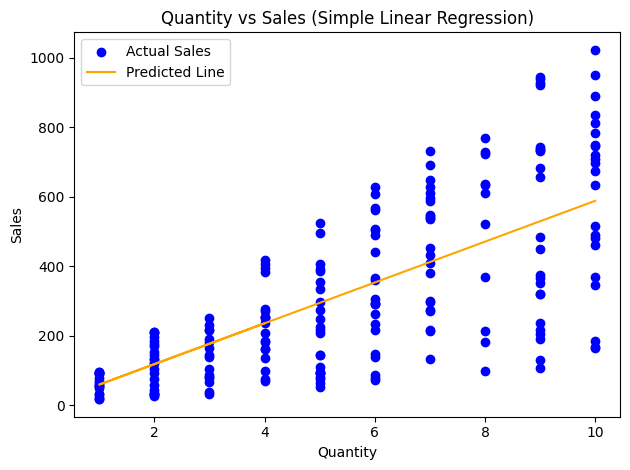

In [ ]:
#  1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#  2. Load Dataset
data = pd.read_csv("SuperMarket Analysis.csv")
print(data.head())

#  3. Define Independent and Dependent Variables
# Independent: Quantity
# Dependent: Sales
X = data[['Quantity']].values
y = data['Sales'].values

#  4. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#  5. Train the Simple Linear Regression Model
simple_regressor = LinearRegression()
simple_regressor.fit(X_train, y_train)

#  6. Predict and Evaluate the Model
y_pred = simple_regressor.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

#  7. Display the Simple Linear Regression Equation
intercept = simple_regressor.intercept_
coefficient = simple_regressor.coef_[0]
print(f"\nSimple Linear Regression Equation:\nSales = {intercept:.2f} + ({coefficient:.2f} * Quantity)")

#  8. Plot Results
plt.scatter(X_test, y_test, color='blue', label='Actual Sales')
plt.plot(X_test, y_pred, color='orange', label='Predicted Line')
plt.title('Quantity vs Sales (Simple Linear Regression)')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()


# **Multiple Linear Regression**

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

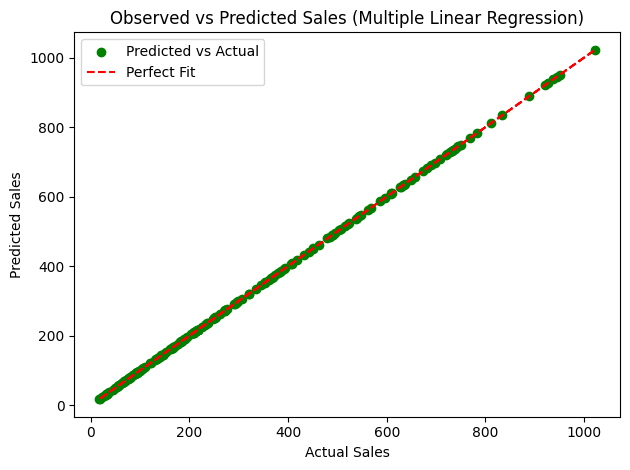

In [ ]:
# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#  2. Load Dataset
data = pd.read_csv("SuperMarket Analysis.csv")
print(data.head())

#  3. Define Independent and Dependent Variables
# Independent: Unit price, Quantity, Rating, gross income
# Dependent: Sales
X = data[['Unit price', 'Quantity', 'Rating', 'gross income']].values
y = data['Sales'].values

#  4. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#  5. Train the Multiple Linear Regression Model
multi_regressor = LinearRegression()
multi_regressor.fit(X_train, y_train)

#  6. Predict and Evaluate the Model
y_pred = multi_regressor.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

#  7. Display the Multiple Linear Regression Equation
coefficients = multi_regressor.coef_
intercept = multi_regressor.intercept_
features = ['Unit price', 'Quantity', 'Rating', 'gross income']

equation = f"Sales = {intercept:.2f} "
for feature, coef in zip(features, coefficients):
    equation += f"+ ({coef:.2f} * {feature}) "

print("\nMultiple Linear Regression Equation:")
print(equation)

#  8. Plot Results (Optional)
plt.scatter(y_test, y_pred, color='green', label="Predicted vs Actual")
plt.plot(y_test, y_test, color='red', linestyle='--', label="Perfect Fit")
plt.title('Observed vs Predicted Sales (Multiple Linear Regression)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#  1. Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

#  2. Load Dataset
df = pd.read_csv('SuperMarket Analysis.csv')
df = df.drop(columns=['Sales', 'gross income'])
df['Sales'] = df['Unit price'] * df['Quantity']

#  3. Define Independent and Dependent Variables
X = df.drop(columns=['Sales', 'Unit price', 'Quantity'])
y = df['Sales']

#  4. Handle Categorical Features
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names, index=X.index)
X_final = pd.concat([X_encoded_df, X[numeric_cols]], axis=1)

#  5. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

#  6. Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

#  7. Predict and Evaluate the Model
y_pred = model.predict(X_test)
print('Final R² Score:', r2_score(y_test, y_pred))


Final R² Score: 0.9999999999999978


# **Logistic Regression**

In [ ]:
# Logistic Regression

# a. Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# b. Importing the dataset
data = pd.read_csv('SuperMarket Analysis.csv')
features = [
    	'Quantity', 'cogs', 'gross income', 'Rating', 'Sales',
    'Unit price','Tax 5%']
X = data[features].values  # Convert to numpy array
y = data['Customer type'].values  # 'Member' or 'Normal'

# c. Encode the categorical dependent variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# d. Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# e. Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# f. Training the Logistic Regression model on the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

# g. Making the Confusion Matrix and evaluating performance
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)


# Step H: Evaluate model performance
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

# Display confusion matrix and accuracy
print("Confusion Matrix:")
print(cm)
print("\nModel Accuracy: {:.2f}%".format(acc * 100))

# Step I: Predict a new sample (example values)
new_sample = [[5, 200, 25, 7.5,80,58,16]]  # Quantity, cogs, gross income, Rating
new_sample_scaled = sc.transform(new_sample)

# Predict the customer type
predicted_class = classifier.predict(new_sample_scaled)
print("\nPredicted Customer Type for New Sample:",
      "Member" if predicted_class[0] == 1 else "Normal")


Confusion Matrix:
[[130   5]
 [113   2]]

Model Accuracy: 52.80%

Predicted Customer Type for New Sample: Normal


# **KNN**

In [ ]:
# Step A: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Encode categorical features
le = LabelEncoder()


# Step B: Load the dataset
data = pd.read_csv('SuperMarket Analysis.csv')

# Step C: Prepare the data - Select relevant features and target
# Let's use 'Customer type' as our target variable (categorical)
features = [
    'Quantity', 'cogs', 'gross income', 'Rating', 'Sales',
    'Unit price','Tax 5%']
X = data[features].values  # Convert to numpy array
y = data['Customer type'].values  # 'Member' or 'Normal'

# Encode the target variable if needed (Member=1, Normal=0)
le = LabelEncoder()
y = le.fit_transform(y)

# Step D: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Step E: Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Step F: Train the KNN model
classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(X_train, y_train)

# Step G: Predict on the test set
y_pred = classifier.predict(X_test)

# Step H: Evaluate model performance
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

# Display confusion matrix and accuracy
print("Confusion Matrix:")
print(cm)
print("\nModel Accuracy: {:.2f}%".format(acc * 100))

# Step I: Predict a new sample (example values)
new_sample = [[5, 200, 25, 7.5,80,58,16]]  # Quantity, cogs, gross income, Rating
new_sample_scaled = sc.transform(new_sample)

# Predict the customer type
predicted_class = classifier.predict(new_sample_scaled)
print("\nPredicted Customer Type for New Sample:",
      "Member" if predicted_class[0] == 1 else "Normal")

Confusion Matrix:
[[89 46]
 [71 44]]

Model Accuracy: 53.20%

Predicted Customer Type for New Sample: Normal


# **Naïve-Bayes**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# Step 2: Load the dataset
data = pd.read_csv('SuperMarket Analysis.csv')

# Step 3: Prepare the data - Select relevant features and target
# Let's use 'Customer type' as our target variable (categorical)

features = [
    'Quantity', 'cogs', 'gross income', 'Rating', 'Sales',
    'Unit price','Tax 5%']
X = data[features].values  # Convert to numpy array
y = data['Customer type'].values  # 'Member' or 'Normal'

# Step 4: Split the dataset into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Step 5: Feature Scaling (important for distance-based models like NB)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Step 6: Train the Naïve Bayes classifier (GaussianNB for continuous data)
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Step 7: Predict values on the test set
y_pred = classifier.predict(X_test)

# Step 8: Evaluate the model using confusion matrix and accuracy
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Display confusion matrix and accuracy
print("Confusion Matrix:")
print(cm)
print("\nModel Accuracy: {:.2f}%".format(accuracy * 100))

# Step I: Predict a new sample (example values)
new_sample = [[5, 200, 25, 7.5,80,58,16]]  # Quantity, cogs, gross income, Rating
new_sample_scaled = sc.transform(new_sample)

# Predict the customer type
predicted_class = classifier.predict(new_sample_scaled)
print("\nPredicted Customer Type for New Sample:",
      "Member" if predicted_class[0] == 1 else "Normal")

Confusion Matrix:
[[57 52]
 [43 48]]

Model Accuracy: 52.50%

Predicted Customer Type for New Sample: Normal


# **Decision Tree**

In [ ]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Step 2: Load the dataset
data = pd.read_csv('SuperMarket Analysis.csv')

# Step 3: Prepare the data - Select relevant features and target
# Let's use 'Customer type' as our target variable (categorical)

features = [
    'Quantity', 'cogs', 'gross income', 'Rating', 'Sales',
    'Unit price','Tax 5%']
X = data[features].values  # Convert to numpy array
y = data['Customer type'].values  # 'Member' or 'Normal'


# Step 3: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Step 4: Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Step 5: Train the Decision Tree model
classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = classifier.predict(X_test)

# Step 7: Evaluate using confusion matrix and accuracy
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy Score: {:.2f}%".format(accuracy * 100))


# Step 8: Predicting a new value
#Example input (based on your image): replace with actual feature count
#Predicting a new sample using the trained Decision Tree model
# Make sure this input has the SAME number of features (columns) used during training
new_sample = sc.transform([[7, 522.83, 26.1415, 9.1, 548.9715, 74.69, 26.1415]])  # Sample with 9 input features

# Step 8: Predicting a new sample using the trained Decision Tree model

# Make sure the number of features is 9 (same as training data)
# Do NOT include extra columns like IDs unless they were part of training
new_sample = sc.transform([[9, 300, 12, 5.2, 200, 50, 10]])  # 9 features
prediction = classifier.predict(new_sample)

# Print the prediction result
print("Prediction for new sample:", prediction)

Confusion Matrix:
 [[76 59]
 [57 58]]

Accuracy Score: 53.60%
Prediction for new sample: ['Member']


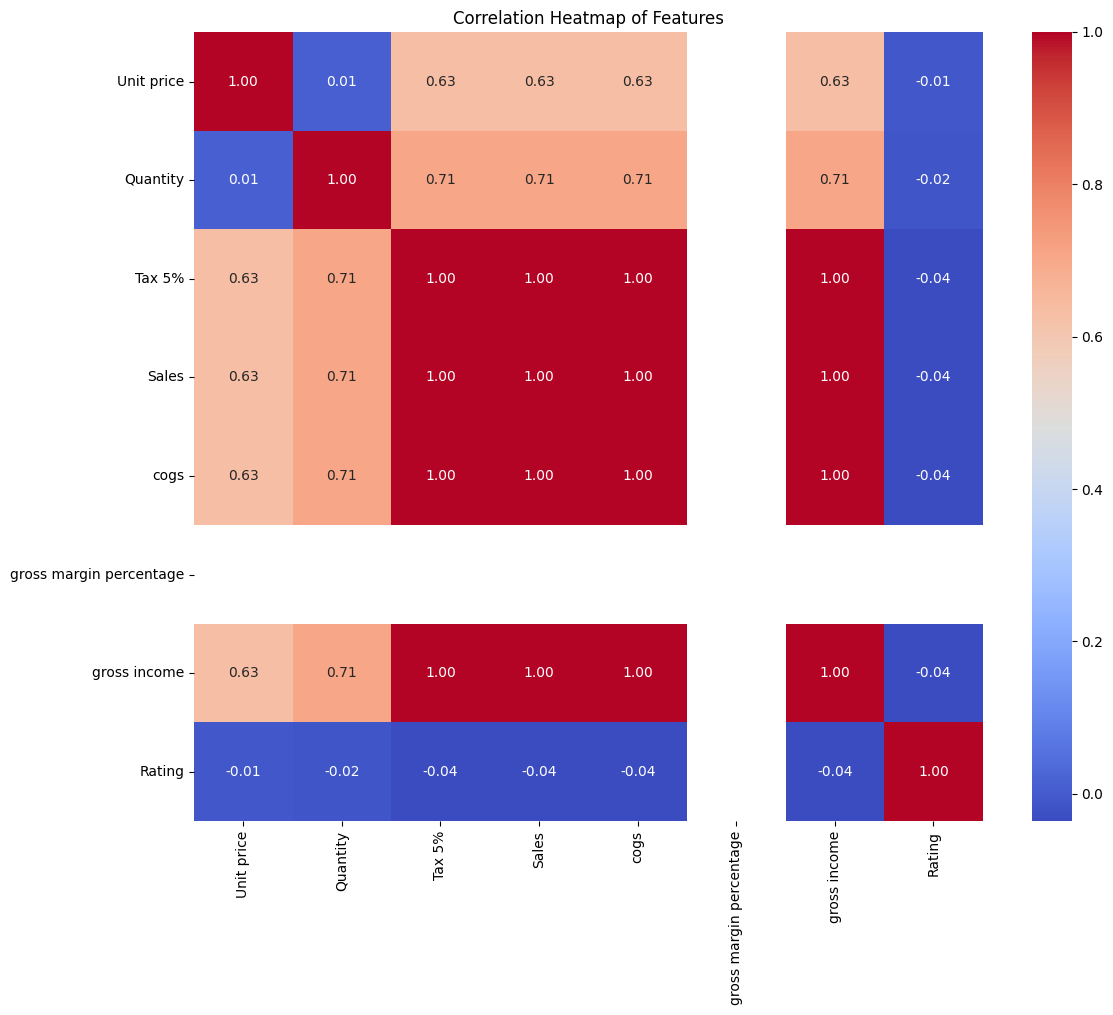

In [ ]:
import pandas as pd #handling datasets
import numpy as np #numerical calculations
import matplotlib.pyplot as plt #plot graphs
import seaborn as sns
# Load the dataset
data = pd.read_csv('SuperMarket Analysis.csv')
# Compute correlation matrix
corr_matrix = data.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()


# **Final Updated Classifier Code for Cleaned Dataset**

In [ ]:
# Final Updated Classifier Code for Cleaned Dataset

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load the cleaned dataset
df_cleaned = pd.read_csv("Cleaned_SuperMarket.csv")

# Step 2: Separate features and target
X = df_cleaned.drop("Customer type", axis=1)
y = df_cleaned["Customer type"]

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Initialize and train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Step 6: Evaluate and compare models
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

# Step 7: Display results
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.2f}")


Logistic Regression: 0.58
Random Forest: 0.52
Decision Tree: 0.51
Naive Bayes: 0.60
K-Nearest Neighbors: 0.51


# **cluster**

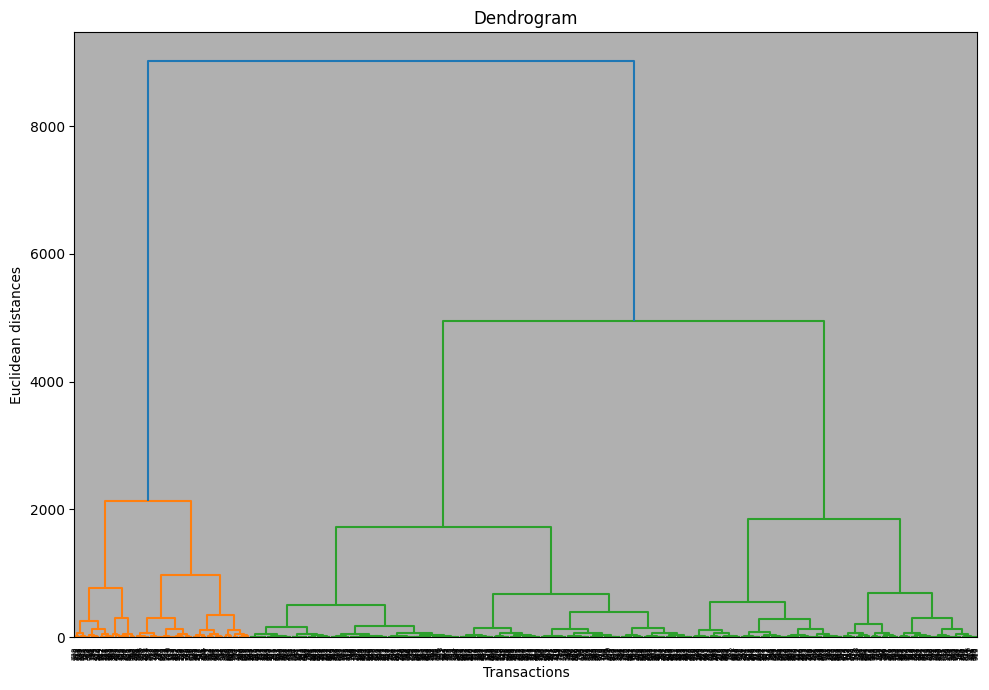

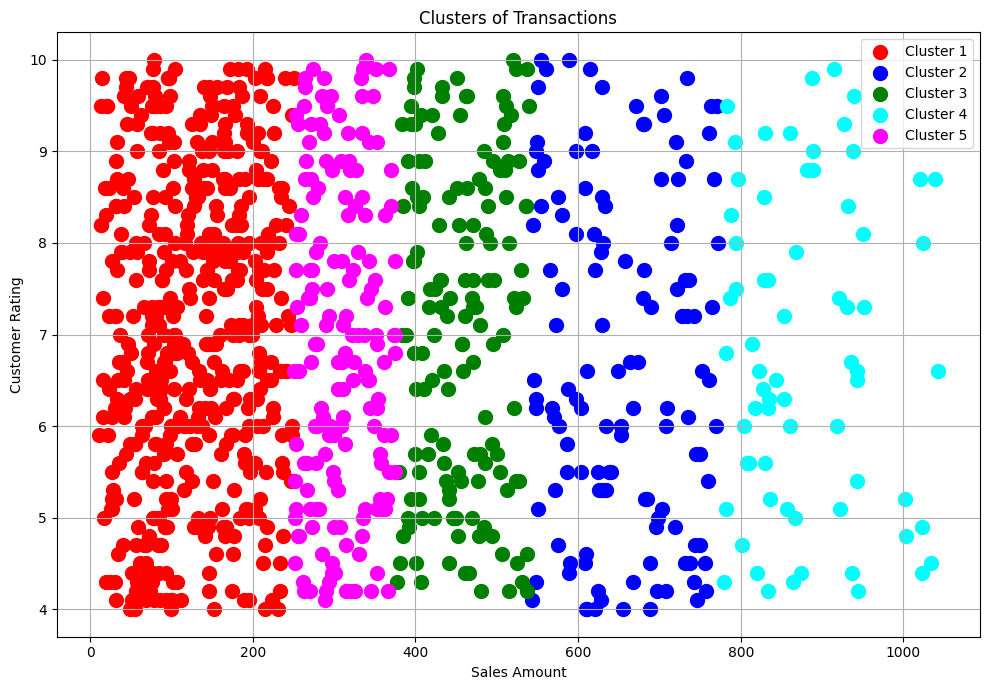

Cluster visualization completed.
Interpretation:
- Analyze clusters based on sales performance and customer satisfaction.
- High Sales & High Rating customers can be targeted for loyalty programs.
- Low Sales & Low Rating transactions could indicate issues needing attention.
              Sales    Rating
Cluster                      
0        125.460031  7.037067
1        654.200250  6.734921
2        455.526997  7.110067
3        881.559463  6.805882
4        307.934196  6.907831


In [ ]:
# Hierarchical Clustering on SuperMarket Data (Updated)

import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Load the dataset
dataset = pd.read_csv("SuperMarket Analysis.csv")

# Selecting the relevant features for clustering (Sales and Rating)
X = dataset[['Sales', 'Rating']].values

# Step 1: Create Dendrogram to determine optimal number of clusters
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Transactions")
plt.ylabel("Euclidean distances")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 2: Apply Agglomerative Clustering (choose 5 clusters based on dendrogram)
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

# Step 3: Visualize the clusters
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(5):
    plt.scatter(X[y_hc == i, 0], X[y_hc == i, 1], s=100, c=colors[i], label=labels[i])

plt.title("Clusters of Transactions")
plt.xlabel("Sales Amount")
plt.ylabel("Customer Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Cluster visualization completed.")
print("Interpretation:")
print("- Analyze clusters based on sales performance and customer satisfaction.")
print("- High Sales & High Rating customers can be targeted for loyalty programs.")
print("- Low Sales & Low Rating transactions could indicate issues needing attention.")

# For Hierarchical Clustering
cluster_summary = pd.DataFrame({'Sales': X[:, 0], 'Rating': X[:, 1], 'Cluster': y_hc})
print(cluster_summary.groupby('Cluster').mean())

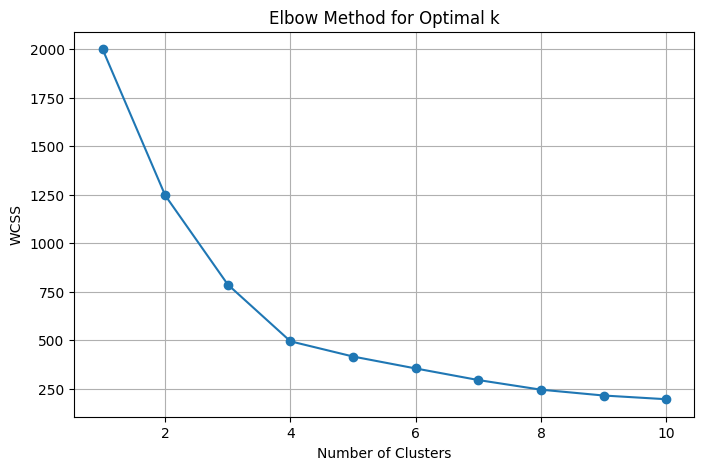

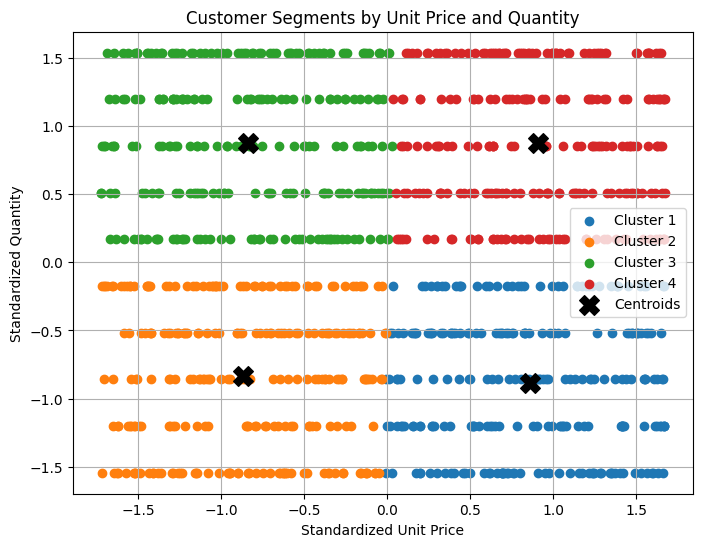

         Unit price  Quantity
Cluster                      
0         78.399795  2.918033
1         32.734615  3.069231
2         33.489036  8.064257
3         79.727976  8.064777


In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler



# Load the dataset

data = pd.read_csv('SuperMarket Analysis.csv')



# Step 1: Select features

X = data[['Unit price', 'Quantity']]



# Step 2: Standardize features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



# Step 3: Determine optimal k using Elbow Method

wcss = []

for i in range(1, 11):

    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)



plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method for Optimal k')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.grid(True)

plt.show()



# Step 4: Apply KMeans with optimal k = 4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X_scaled)



# Step 5: Visualize the clusters

plt.figure(figsize=(8, 6))

plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], label='Cluster 1')

plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], label='Cluster 2')

plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], label='Cluster 3')

plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], label='Cluster 4')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='X', label='Centroids')



plt.title('Customer Segments by Unit Price and Quantity')

plt.xlabel('Standardized Unit Price')

plt.ylabel('Standardized Quantity')

plt.legend()

plt.grid(True)

plt.show()


# For KMeans Clustering
cluster_summary_kmeans = pd.DataFrame({'Unit price': X['Unit price'], 'Quantity': X['Quantity'], 'Cluster': y_kmeans})
print(cluster_summary_kmeans.groupby('Cluster').mean())